# Fine-tune SciBERT v2 — PubMed 20k + ACL Anthology Negative Examples

Labels: BACKGROUND, OBJECTIVE, METHODS, RESULTS, CONCLUSIONS, NONE

**Strategy:**
1. Load PubMed 20k RCT abstracts as positive examples (5 facet labels)
2. Download ACL Anthology corpus parquet (73k NLP papers, full text + abstract)
3. Embed sentences + abstract with SPECTER2
4. Label sentences with cosine similarity < threshold to their paper abstract as NONE
5. Fine-tune SciBERT from scratch on the combined dataset

In [1]:
!pip install transformers datasets scikit-learn nltk gdown -q

In [2]:
from google.colab import drive
import zipfile

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Human-AI Class Project/archive.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")
!ls

Mounted at /content/drive
drive
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
sample_data


## 1. Load PubMed 20k positive examples

In [27]:
import pandas as pd

DATA_DIR = "/content/PubMed_20k_RCT"

train_raw = pd.read_csv(f"{DATA_DIR}/train.csv")
val_raw   = pd.read_csv(f"{DATA_DIR}/dev.csv")
test_raw  = pd.read_csv(f"{DATA_DIR}/test.csv")

print(train_raw.head())
print("Columns:", train_raw.columns.tolist())
print(f"Train: {len(train_raw)}  Val: {len(val_raw)}  Test: {len(test_raw)}")

   abstract_id        line_id  \
0     24293578  24293578_0_12   
1     24293578  24293578_1_12   
2     24293578  24293578_2_12   
3     24293578  24293578_3_12   
4     24293578  24293578_4_12   

                                       abstract_text  line_number  \
0  To investigate the efficacy of 6 weeks of dail...            0   
1  A total of 125 patients with primary knee OA w...            1   
2  Outcome measures included pain reduction and i...            2   
3  Pain was assessed using the visual analog pain...            3   
4  Secondary outcome measures included the Wester...            4   

   total_lines     target  
0           12  OBJECTIVE  
1           12    METHODS  
2           12    METHODS  
3           12    METHODS  
4           12    METHODS  
Columns: ['abstract_id', 'line_id', 'abstract_text', 'line_number', 'total_lines', 'target']
Train: 180040  Val: 30212  Test: 30135


In [28]:
TEXT_COL  = "abstract_text"
LABEL_COL = "target"

# Normalise label names to match your classifier.py conventions
LABEL_MAP = {
    "BACKGROUND":   "BACKGROUND",
    "OBJECTIVE":    "OBJECTIVE",
    "METHODS":      "METHODS",
    "METHOD":       "METHODS",
    "RESULTS":      "RESULTS",
    "RESULT":       "RESULTS",
    "CONCLUSIONS":  "CONCLUSIONS",
    "CONCLUSION":   "CONCLUSIONS",
}

def prepare(df):
    df = df[[TEXT_COL, LABEL_COL]].dropna().copy()
    df.columns = ["text", "label"]
    df["label"] = df["label"].str.upper().map(LABEL_MAP)
    return df.dropna(subset=["label"])

pubmed_train = prepare(train_raw)
pubmed_val   = prepare(val_raw)
pubmed_test  = prepare(test_raw)

print("PubMed label distribution (train):")
print(pubmed_train["label"].value_counts())

PubMed label distribution (train):
label
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64


## 2. Load ACLSum train split and build in-domain labeled sentences

**Strategy:** Use ACLSum's gold annotations to get ACL-domain examples for all classes:
- `challenge_sentences` → soft label [0.5 BACKGROUND, 0.5 OBJECTIVE] — either is acceptable
- `approach_sentences`  → hard label [1.0 METHODS]
- `outcome_sentences`   → soft label [0.5 CONCLUSIONS, 0.5 RESULTS]
- non-highlighted `source_sentences` → hard label [1.0 NONE]

PubMed 20k provides label-smoothed hard labels (ε=0.1) for all 5 facet classes.
Combined training eliminates domain mismatch between positive classes and NONE.

In [29]:
from datasets import load_dataset
import pandas as pd

# Label order must match label2id defined below
# BACKGROUND=0, CONCLUSIONS=1, METHODS=2, NONE=3, OBJECTIVE=4, RESULTS=5
LABEL_NAMES = ["BACKGROUND", "CONCLUSIONS", "METHODS", "NONE", "OBJECTIVE", "RESULTS"]
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label  = {i: l for l, i in label2id.items()}

def make_soft(probs: dict) -> list:
    """Convert {label: weight} dict to a probability vector."""
    vec = [0.0] * len(LABEL_NAMES)
    for label, w in probs.items():
        vec[label2id[label]] = w
    return vec

print("Loading ACLSum train split...")
aclsum_train = load_dataset("sobamchan/aclsum", "extractive", split="train")
print(f"  {len(aclsum_train)} papers")

records = []  # each: {"text": str, "soft_label": [float x 6]}

for paper in aclsum_train:
    src    = paper["source_sentences"]
    ch_set = set(paper["challenge_sentences"])
    ap_set = set(paper["approach_sentences"])
    out_set= set(paper["outcome_sentences"])
    highlighted = ch_set | ap_set | out_set

    for sent in src:
        if sent in ch_set:
            soft = make_soft({"OBJECTIVE": 1.0})
        elif sent in ap_set:
            soft = make_soft({"METHODS": 1.0})
        elif sent in out_set:
            soft = make_soft({"CONCLUSIONS": 0.5, "RESULTS": 0.5})
        else:
            soft = make_soft({"NONE": 1.0})
        records.append({"text": sent, "soft_label": soft})

acl_df = pd.DataFrame(records)
print(f"  {len(acl_df)} sentences total")
print(f"  Label breakdown:")
import numpy as np
arr = np.array(acl_df["soft_label"].tolist())
for i, name in enumerate(LABEL_NAMES):
    n = (arr[:, i] > 0).sum()
    print(f"    {name:>12}: {n:>6}")

Loading ACLSum train split...
  100 papers
  3868 sentences total
  Label breakdown:
      BACKGROUND:      0
     CONCLUSIONS:    442
         METHODS:    717
            NONE:   2254
       OBJECTIVE:    455
         RESULTS:    442


## 3. Build soft-labeled PubMed examples and combine datasets

In [30]:
from sklearn.model_selection import train_test_split
import numpy as np

SMOOTH = 0.1  # label smoothing epsilon for PubMed hard labels

# Cap PubMed per class to speed up training
MAX_PUBMED_PER_CLASS = 10000
# Cap ACLSum NONE examples to keep class balance
MAX_ACL_NONE = 10000

def pubmed_soft(label: str) -> list:
    K = len(LABEL_NAMES)
    vec = [SMOOTH / (K - 1)] * K
    vec[label2id[label]] = 1.0 - SMOOTH
    return vec

def to_soft_df(df):
    K = len(LABEL_NAMES)
    soft = np.full((len(df), K), SMOOTH / (K - 1), dtype=np.float32)
    for i, label in enumerate(df["label"]):
        soft[i, label2id[label]] = 1.0 - SMOOTH
    return pd.DataFrame({"text": df["text"].tolist(), "soft_label": soft.tolist()})

def cap_per_class(df, max_per_class):
    return pd.concat([
        g.sample(min(len(g), max_per_class), random_state=42)
        for _, g in df.groupby("label")
    ])

pm_train_soft = to_soft_df(cap_per_class(pubmed_train, MAX_PUBMED_PER_CLASS))
pm_val_soft   = to_soft_df(cap_per_class(pubmed_val,   MAX_PUBMED_PER_CLASS // 5))
pm_test_soft  = to_soft_df(cap_per_class(pubmed_test,  MAX_PUBMED_PER_CLASS // 5))

print("PubMed after capping:")
print(f"  train:{len(pm_train_soft)}  val:{len(pm_val_soft)}  test:{len(pm_test_soft)}")

# Split ACLSum records into train/val/test, cap NONE
acl_train_df, acl_tmp = train_test_split(acl_df, test_size=0.2, random_state=42)
acl_val_df, acl_test_df = train_test_split(acl_tmp, test_size=0.5, random_state=42)

def cap_none(df, max_none):
    arr = np.array(df["soft_label"].tolist())
    is_none = arr.argmax(axis=1) == label2id["NONE"]
    none_idx     = df.index[is_none].tolist()
    non_none_idx = df.index[~is_none].tolist()
    if len(none_idx) > max_none:
        none_idx = none_idx[:max_none]
    return df.loc[sorted(non_none_idx + none_idx)].reset_index(drop=True)

acl_train_df = cap_none(acl_train_df, MAX_ACL_NONE)
acl_val_df   = cap_none(acl_val_df,   MAX_ACL_NONE // 5)
acl_test_df  = cap_none(acl_test_df,  MAX_ACL_NONE // 5)

print("ACLSum after capping:")
print(f"  train:{len(acl_train_df)}  val:{len(acl_val_df)}  test:{len(acl_test_df)}")

# Combine and shuffle train
train_df = pd.concat([pm_train_soft, acl_train_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
val_df   = pd.concat([pm_val_soft,   acl_val_df],   ignore_index=True)
test_df  = pd.concat([pm_test_soft,  acl_test_df],  ignore_index=True)

print(f"\nCombined - Train:{len(train_df)}  Val:{len(val_df)}  Test:{len(test_df)}")
print("\nTrain soft-label breakdown (dominant label per example):")
arr = np.array(train_df["soft_label"].tolist())
dominant = arr.argmax(axis=1)
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:>12}: {(dominant == i).sum():>6}")

PubMed after capping:
  train:50000  val:10000  test:10000
ACLSum after capping:
  train:3094  val:387  test:387

Combined - Train:53094  Val:10387  Test:10387

Train soft-label breakdown (dominant label per example):
    BACKGROUND:  10000
   CONCLUSIONS:  10356
       METHODS:  10586
          NONE:   1798
     OBJECTIVE:  10354
       RESULTS:  10000


## 4. Tokenize

In [31]:
from transformers import AutoTokenizer
from datasets import Dataset
import numpy as np

MODEL_NAME = "allenai/scibert_scivocab_uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

def to_hf_dataset(df):
    records = {"text": df["text"].tolist(),
               "labels": df["soft_label"].tolist()}
    ds = Dataset.from_dict(records)
    ds = ds.map(tokenize, batched=True)
    ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

train_ds = to_hf_dataset(train_df)
val_ds   = to_hf_dataset(val_df)
test_ds  = to_hf_dataset(test_df)

print("Datasets ready")
print(f"  Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"  Label shape per example: {train_ds[0]['labels'].shape}")

Map:   0%|          | 0/53094 [00:00<?, ? examples/s]

Map:   0%|          | 0/10387 [00:00<?, ? examples/s]

Map:   0%|          | 0/10387 [00:00<?, ? examples/s]

Datasets ready
  Train: 53094  Val: 10387  Test: 10387
  Label shape per example: torch.Size([6])


## 5. Train with soft-label cross-entropy

In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

class SoftLabelTrainer(Trainer):
    """Trainer that uses KL-divergence loss for soft targets."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        soft_labels = inputs.pop("labels").float()          # (B, K)
        outputs = model(**inputs)
        log_probs = F.log_softmax(outputs.logits, dim=-1)   # (B, K)
        # KLDiv: expects log-probs as input, probs as target
        loss = F.kl_div(log_probs, soft_labels, reduction="batchmean")
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    hard_labels = labels.argmax(axis=-1)
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(hard_labels, preds),
        "f1_macro": f1_score(hard_labels, preds, average="macro"),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_NAMES),
    id2label=id2label,
    label2id=label2id,
)

training_args = TrainingArguments(
    output_dir="scibert-acl-v4",
    num_train_epochs=5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    bf16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused",
)

from transformers import EarlyStoppingCallback

trainer = SoftLabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.384756,0.348933,0.808992,0.796038
2,0.311526,0.338019,0.812073,0.801572
3,0.234744,0.359305,0.811014,0.800378
4,0.167854,0.406515,0.804948,0.793200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1660, training_loss=0.28624020082404816, metrics={'train_runtime': 576.1771, 'train_samples_per_second': 460.744, 'train_steps_per_second': 3.601, 'total_flos': 1.2404575691718192e+16, 'train_loss': 0.28624020082404816, 'epoch': 4.0})

## 6. Evaluate on test set

In [33]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_ds)
logits = predictions.predictions
soft_labels = predictions.label_ids

preds       = logits.argmax(axis=-1)
hard_labels = soft_labels.argmax(axis=-1)

print(classification_report(hard_labels, preds, target_names=LABEL_NAMES))

              precision    recall  f1-score   support

  BACKGROUND       0.67      0.73      0.70      2000
 CONCLUSIONS       0.85      0.81      0.83      2048
     METHODS       0.88      0.92      0.90      2060
        NONE       0.69      0.79      0.74       228
   OBJECTIVE       0.77      0.66      0.71      2051
     RESULTS       0.87      0.90      0.88      2000

    accuracy                           0.80     10387
   macro avg       0.79      0.80      0.79     10387
weighted avg       0.80      0.80      0.80     10387



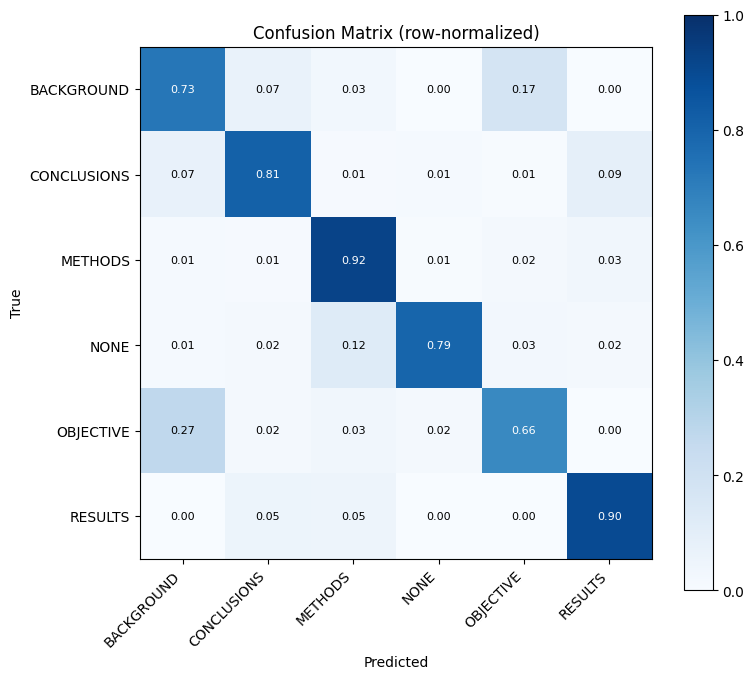

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(hard_labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(LABEL_NAMES)))
ax.set_yticks(range(len(LABEL_NAMES)))
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha="right")
ax.set_yticklabels(LABEL_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized)")
for i in range(len(LABEL_NAMES)):
    for j in range(len(LABEL_NAMES)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Save model

In [35]:
import json, shutil

SAVE_PATH  = "scibert-acl-v4-final"
DRIVE_PATH = "/content/drive/MyDrive/human-ai class project/scibert-acl-v4-final"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(f"{SAVE_PATH}/label_map.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f)

shutil.make_archive(DRIVE_PATH, "zip", SAVE_PATH)
print(f"Saved to {DRIVE_PATH}.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/human-ai class project/scibert-acl-v4-final.zip


In [ ]:
# Alternative: download directly without Drive
from google.colab import files

shutil.make_archive(SAVE_PATH, "zip", SAVE_PATH)
files.download(f"{SAVE_PATH}.zip")
print("Done — unzip into service/ and update MODEL_DIR in classifier.py")